In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline

In [2]:
df=pd.read_csv('height-weight.csv')

In [3]:
df.head()

,Weight,Height
0,45,120
1,58,135
2,48,123
3,60,145
4,70,160


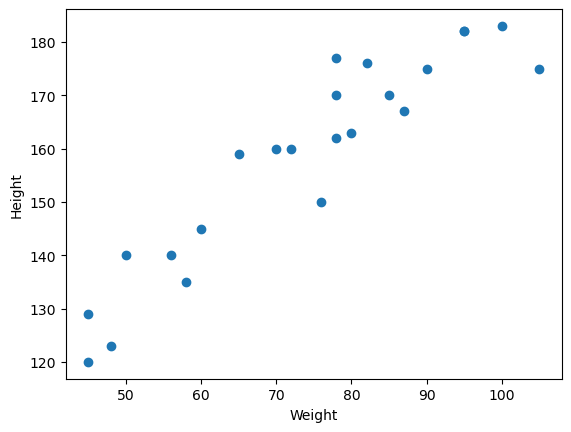

In [4]:
### Scatter plot
plt.scatter(df['Weight'], df['Height'])
plt.xlabel('Weight')
plt.ylabel('Height')
plt.show()

In [5]:
## correlation
df.corr()

,Weight,Height
Weight,1.000000,0.931142
Height,0.931142,1.000000


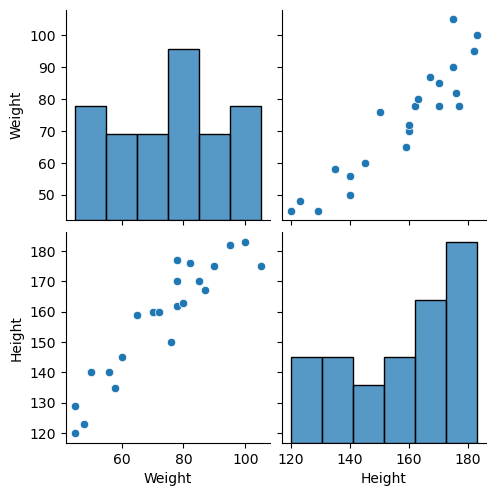

In [6]:
## Seaborn for visualization
import seaborn as sns
sns.pairplot(df)

In [7]:
## Independent and dependent features

X = df.drop('Height', axis=1) ## Independent features. This should be a dataframe or 2 dimensional array

In [8]:
X.head()

,Weight
0,45
1,58
2,48
3,60
4,70


In [9]:
y = df['Height'] ## The dependent feature needs to be a series or 1 dimension
y.head()

0    120
1    135
2    123
3    145
4    160
Name: Height, dtype: int64

In [10]:
X.shape

(23, 1)

In [11]:
np.array(X).shape ## same as above

(23, 1)

In [12]:
y.shape

(23,)

In [13]:
## Train Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.25,random_state=42)

In [14]:
X_train.shape

(17, 1)

In [15]:
y_train.shape

(17,)

In [16]:
## Standardization
from sklearn.preprocessing import StandardScaler


In [17]:
scaler = StandardScaler()
X_train=scaler.fit_transform(X_train)

In [18]:
X_test=scaler.transform(X_test)
X_test

array([[ 0.33497168],
       [ 0.33497168],
       [-1.6641678 ],
       [ 1.36483141],
       [-0.45256812],
       [ 1.97063125]])

In [19]:
## Appliy Simple Linear regression
from sklearn.linear_model import LinearRegression

In [20]:
regression=LinearRegression(n_jobs=-1)

In [21]:
regression.fit(X_train,y_train)

LinearRegression(n_jobs=-1)

In [22]:
## Lets get the returned values
print('Coefficient or Slope:', regression.coef_) 
print('Intercept:', regression.intercept_)

Coefficient or Slope: [17.2982057]
Intercept: 156.47058823529412


In [23]:
## Let us get the predicted values Using X_train
y_train_predict = regression.predict(X_train)
y_train_predict ## We will use this to view the model line (Best fit line)

array([141.30649667, 185.31934779, 162.26499721, 130.82724641,
       180.07972266, 127.68347133, 143.40234673, 153.88159699,
       160.16914715, 132.92309646, 139.21064662, 155.97744705,
       174.84009753, 166.45669731, 169.60047239, 171.69632245,
       164.36084726])

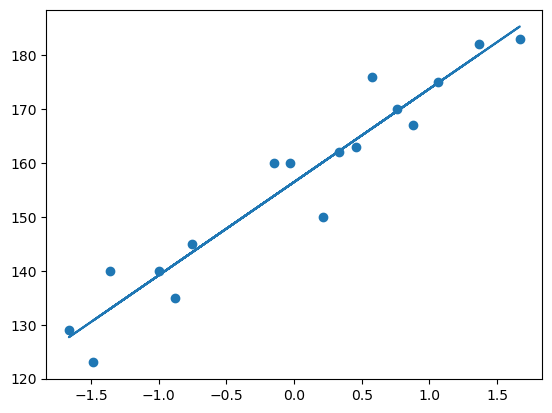

In [24]:
## Lets plot training data with the best-fit data
plt.scatter(X_train,y_train)
plt.plot(X_train, y_train_predict) ## THe best fit line

In [25]:
### Prediction Test data
# 1. predicted height outputs = intercept + coef_(Weights)
# 2. y_pred_test = 156.470 + 70.29(X_test)

In [26]:
## Predicton of test data
y_pred = regression.predict(X_test)
y_pred

array([162.26499721, 162.26499721, 127.68347133, 180.07972266,
       148.64197186, 190.55897293])

In [27]:
## Performance Metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mse)

print('Mean Squared error:', mse)
print('Mean Absolute error:', mae)
print('Root Mean Sqaured error:', rmse)




Mean Squared error: 114.84069295228699
Mean Absolute error: 9.665125886795005
Root Mean Sqaured error: 10.716374991212605


In [28]:
## using r squared
from sklearn.metrics import r2_score
score = r2_score(y_test, y_pred)
print('r square:', score)


r square: 0.7360826717981276


It is not very good accuracy but we will go into more advanced methods to improve this model

In [29]:
## Using Adjusted r squared

adjusted_score=1-(1-score)*(len(y_test)-1)/(len(y_test)-X_test.shape[1]-1)
print('Adjusted r square:', adjusted_score)

Adjusted r square: 0.6701033397476595


In [30]:
## OLS Linear Regression (Ordinary Least Square)
import statsmodels.api as sm

In [31]:
model=sm.OLS(y_train, X_train).fit()

In [32]:
prediction=model.predict(X_test)
print(prediction)

[  5.79440897   5.79440897 -28.78711691  23.60913442  -7.82861638
  34.08838469]


In [33]:
print(model.summary())

                                 OLS Regression Results                                
Dep. Variable:                 Height   R-squared (uncentered):                   0.012
Model:                            OLS   Adj. R-squared (uncentered):             -0.050
Method:                 Least Squares   F-statistic:                             0.1953
Date:                Sat, 09 May 2026   Prob (F-statistic):                       0.664
Time:                        18:48:45   Log-Likelihood:                         -110.03
No. Observations:                  17   AIC:                                      222.1
Df Residuals:                      16   BIC:                                      222.9
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

C:\ProgramData\anaconda3\Lib\site-packages\scipy\stats\_axis_nan_policy.py:531: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=17
  res = hypotest_fun_out(*samples, **kwds)


In [34]:
## Prediction for new data
## Lets say we want to predict the height of a person of weight 72

regression.predict([[72]]) ## remember to input with double bracket(dataframe)

array([1401.94139895])

In [35]:
## You can see that the height is not looking accurate
## This is because we standardized the training data
## Therefore we have to standardize any input

regression.predict(scaler.transform([[72]]))

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([155.97744705])

In [36]:
## This is a more correct output

### Multiple Linear Regression

In [37]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline

In [39]:
df_index = pd.read_csv('economic_index.csv')

In [40]:
df_index.head()

,Unnamed: 0,year,month,interest_rate,unemployment_rate,index_price
0,0,2017,12,2.75,5.3,1464
1,1,2017,11,2.50,5.3,1394
2,2,2017,10,2.50,5.3,1357
3,3,2017,9,2.50,5.3,1293
4,4,2017,8,2.50,5.4,1256


In [41]:
## drop unnecessary column eg year and month

df_index=df_index.drop(columns=['Unnamed: 0','year','month'],axis=1)
df_index.head()

,interest_rate,unemployment_rate,index_price
0,2.75,5.3,1464
1,2.50,5.3,1394
2,2.50,5.3,1357
3,2.50,5.3,1293
4,2.50,5.4,1256


In [42]:
## check null values
df_index.isnull().sum()

interest_rate        0
unemployment_rate    0
index_price          0
dtype: int64

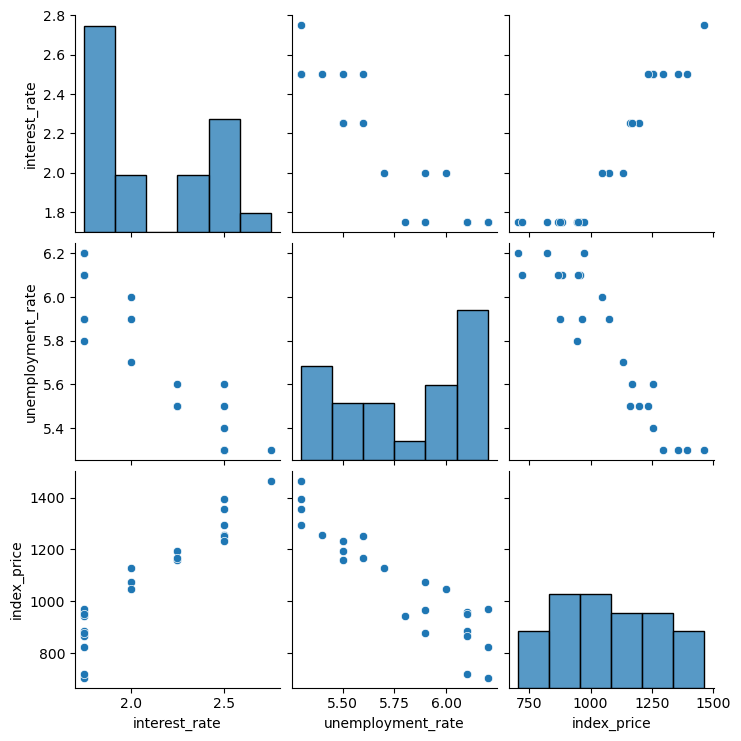

In [43]:
import seaborn as sns
sns.pairplot(data=df_index)

In [44]:
df_index.corr()

,interest_rate,unemployment_rate,index_price
interest_rate,1.000000,-0.925814,0.935793
unemployment_rate,-0.925814,1.000000,-0.922338
index_price,0.935793,-0.922338,1.000000


Text(0, 0.5, 'unemployment_rate')

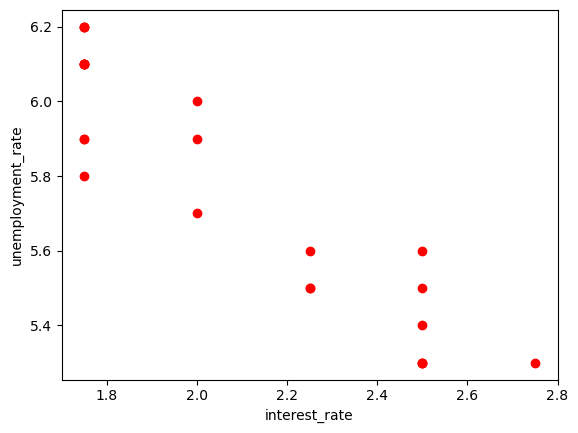

In [47]:
## Visualize the data points more closely

plt.scatter(df_index['interest_rate'], df_index['unemployment_rate'],c='r')
plt.xlabel('interest_rate')
plt.ylabel('unemployment_rate')

In [54]:
## Dependent and independent features (we just decided to use iloc)

X=df_index.iloc[:,:-1] ## takes all rows and all columns, except the last column
y=df_index.iloc[:,-1] ## Take the last column

In [57]:
## Elaboration

df_index.iloc[:,:-1] ## The column side is all_column - 1

,interest_rate,unemployment_rate
0,2.75,5.3
1,2.50,5.3
2,2.50,5.3
3,2.50,5.3
4,2.50,5.4
5,2.50,5.6
6,2.50,5.5
7,2.25,5.5
8,2.25,5.5
9,2.25,5.6


In [60]:
df_index.iloc[:,-1] ## The beauty of iloc here. If you select a single column it comes as a series

0     1464
1     1394
2     1357
3     1293
4     1256
5     1254
6     1234
7     1195
8     1159
9     1167
10    1130
11    1075
12    1047
13     965
14     943
15     958
16     971
17     949
18     884
19     866
20     876
21     822
22     704
23     719
Name: index_price, dtype: int64

In [61]:
### Train test split
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.25,random_state=42)

<Axes: xlabel='interest_rate', ylabel='index_price'>

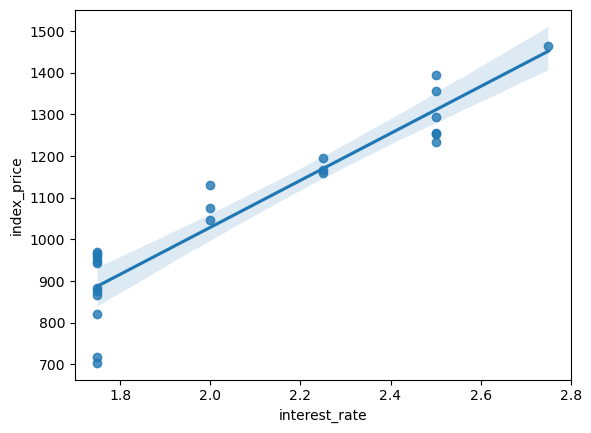

In [67]:
sns.regplot(x=df_index['interest_rate'], y=df_index['index_price'])

<Axes: xlabel='unemployment_rate', ylabel='index_price'>

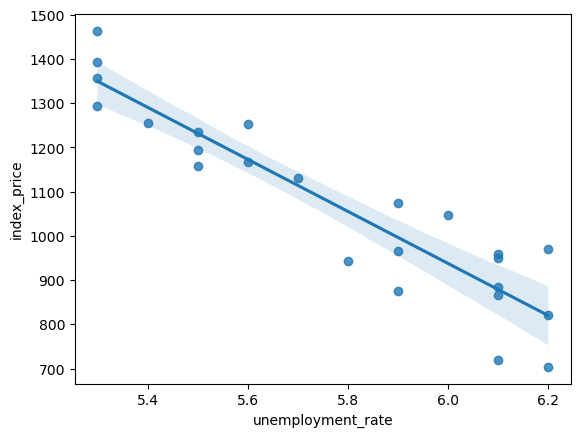

In [68]:
sns.regplot(x=df_index['unemployment_rate'], y=df_index['index_price'])

<Axes: xlabel='interest_rate', ylabel='unemployment_rate'>

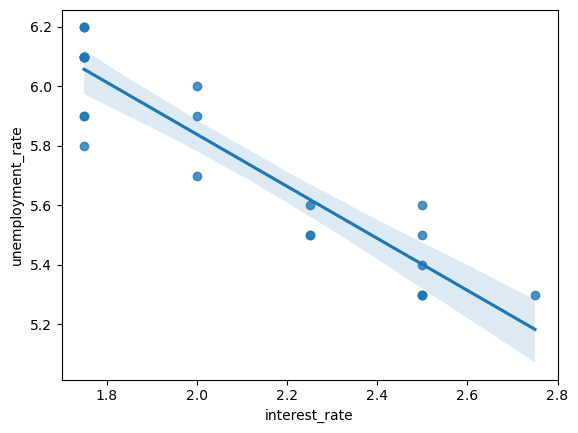

In [69]:
sns.regplot(x=df_index['interest_rate'], y=df_index['unemployment_rate'])

In [71]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test) ## remember not to use fit_transform for the X_test

In [72]:
from sklearn.linear_model import LinearRegression
regression=LinearRegression()

In [73]:
regression.fit(X_train, y_train)

LinearRegression()

#### cross validation

In [74]:
## Let us try cross validation we will com back to this

from sklearn.model_selection import cross_val_score
validation_score = cross_val_score(regression, X_train, y_train, scoring='neg_mean_squared_error',cv=3)

In [75]:
validation_score

array([-4921.61331265, -7686.87497294, -5135.9962549 ])

In [76]:
## prediction
y_pred = regression.predict(X_test)
y_pred

array([1204.22770398,  821.65051903, 1406.51300368,  857.70889608,
        994.90992298, 1168.16932693])

In [77]:
## Performance Metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mse)

print('Mean Squared error:', mse)
print('Mean Absolute error:', mae)
print('Root Mean Sqaured error:', rmse)


Mean Squared error: 5793.76288771258
Mean Absolute error: 59.93578152323554
Root Mean Sqaured error: 76.11677139574813


In [78]:
## using r squared
from sklearn.metrics import r2_score
score = r2_score(y_test, y_pred)
print('r square:', score)


r square: 0.8278978091457142


In [79]:
## Using Adjusted r squared

adjusted_score=1-(1-score)*(len(y_test)-1)/(len(y_test)-X_test.shape[1]-1)
print('Adjusted r square:', adjusted_score)

Adjusted r square: 0.713163015242857


### Assumptions


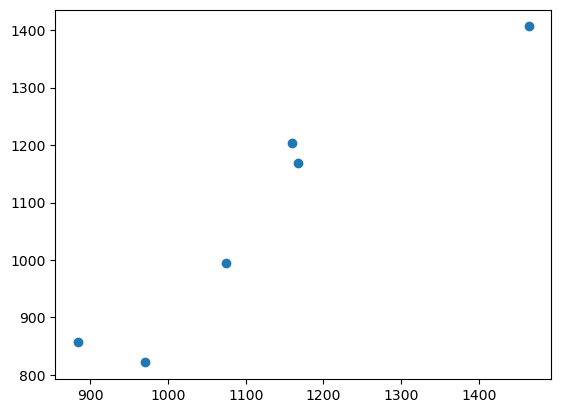

In [80]:
## 1. If there is linear relationship between the y_pred and y_test. The model performed well

plt.scatter(y_test, y_pred)

The relationship looks really good

In [81]:
## 2. We check the residuals. Then plot the kde plot. If it has a normal distribution then the model is good
residuals = y_test-y_pred
print(residuals)


8     -45.227704
16    149.349481
0      57.486996
18     26.291104
11     80.090077
9      -1.169327
Name: index_price, dtype: float64


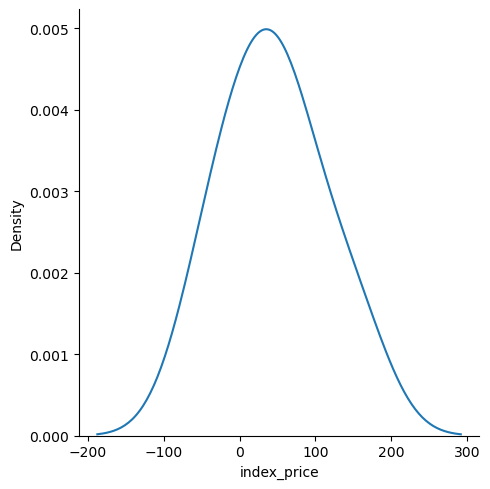

In [82]:
## plot the residuals
sns.displot(residuals,kind='kde')

The above looks really good. The residuals are normally distributed

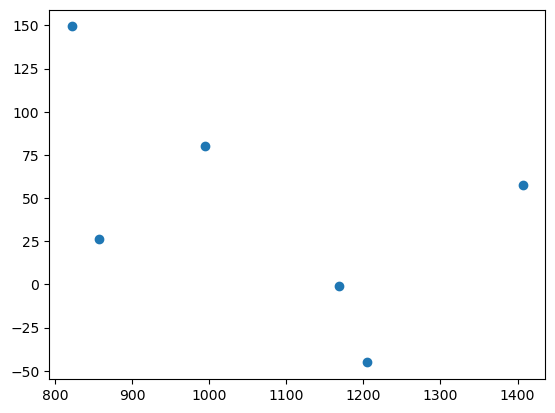

In [83]:
## 3. Create scatter plot with respect to prediction and residuals. If it is uniformly distributed (not showing any pattern) it is a good model


plt.scatter(y_pred, residuals)

The above is uniformly distributed. Therefore it is a good model

In [85]:
### OLS Linear Regression
import statsmodels.api as sm
model=sm.OLS(y_train, X_train).fit()

In [87]:
model.summary()

C:\ProgramData\anaconda3\Lib\site-packages\scipy\stats\_axis_nan_policy.py:531: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=18
  res = hypotest_fun_out(*samples, **kwds)


<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:            index_price   R-squared (uncentered):                   0.035
Model:                            OLS   Adj. R-squared (uncentered):             -0.086
Method:                 Least Squares   F-statistic:                             0.2880
Date:                Sat, 09 May 2026   Prob (F-statistic):                       0.754
Time:                        21:11:56   Log-Likelihood:                         -150.85
No. Observations:                  18   AIC:                                      305.7
Df Residuals:                      16   BIC:                                      307.5
Df Model:                           2                                                  
Covariance Type:            nonrobust                                                  
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
x1            88.2728    658.295      0.134      0.895   -1307.250    1483.796
x2          -116.2572    658.295     -0.177      0.862   -1511.780    1279.266
==============================================================================
Omnibus:                        0.598   Durbin-Watson:                   0.007
Prob(Omnibus):                  0.741   Jarque-Bera (JB):                0.567
Skew:                          -0.361   Prob(JB):                        0.753
Kurtosis:                       2.517   Cond. No.                         4.78
==============================================================================

Notes:
[1] R² is computed without centering (uncentered) since the model does not contain a constant.
[2] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [88]:
## Lets compare the coefficients between the OLS model and the Regression model

regression.coef_

array([  88.27275507, -116.25716066])

In [ ]:
## We can see that the coefficients are the same